# WP2/T2.5 DBRepo – load 
[Owner: C]

Verify whether the schema defined in T2.1 correctly models the data in 3NF. 

If so, prepare code to load
the input data into DBRepo using the REST API and verify that all views defined in T2.4 return correct
results.

*Author*: *Ambrogi Federico*

## Verification of 3NF ----------------------------------------------------------

The actual format of the tables is not in 3NF, as it concerns the *precipitation_measurement* table.
Unfortunately we did not realize in time to change the whole framework.

Anyway, we list here a possible 3NF compliant structure of the table *precipitation_measurement* which contain the follwing variables:

- ions: nh4, na, k, ca, mg, cl, no3, so4, pd, cd
- their quality flags
- ph
- nf (precipitation)
- lf (conductivity)

### Example 3NF Table
A possible 3NF table structure is the following:






In [1]:
import pandas as pd

norm_prec = {'observation_variable' : [1,2,3,4,5] ,
             'observed_value' : [0.19, 3.89, 5.292, 0.003, 0.00938 ] , 
             'date': [ '01012015', '02012015', '03012015', '04012015', '05012015'],
             'quality_flag' : [1,1,7,1,2] , 
             'observation_id': [1,2,3,4,5] }


obs_df = pd.DataFrame.from_dict(norm_prec)
obs_df

,observation_variable,observed_value,date,quality_flag,observation_id
0,1,0.19000,01012015,1,1
1,2,3.89000,02012015,1,2
2,3,5.29200,03012015,7,3
3,4,0.00300,04012015,1,4
4,5,0.00938,05012015,2,5


This allows to identify a primary key as the observation_id variable which extends from 0 to the total number of measured values.

This would satisfy, 1NF,2NF and **3NF**.

## Verification of the SQL VIEWS T2.4 ----------------------------------------------------------

I found no VIEWS stored in the dataset. Therefore,
I implemented some VIEWS here in this notebook for a pair of SQL queries.

To proceed to verify the correct implementation of the SQL queries thorugh the Python API, 
we compare the intended output with data retrieved directly from the source file.

This not only validates the VIEW implementation but partilly the entire workflow implemented this far.





In [2]:
from dbrepo.RestClient import RestClient
from dbrepo.api.dto import (
    QueryDefinition,
    FilterDefinition,
    FilterType,
    OrderDefinition,
    OrderType,
)
import pandas as pd
import time
import os, sys

In [3]:
from dotenv import load_dotenv
load_dotenv("../.env")

ENDPOINT = "https://test.dbrepo.tuwien.ac.at"
USERNAME = os.getenv("DBREPO_USERNAME")
PASSWORD = os.getenv("DBREPO_PASSWORD")
DATABASE_ID = os.getenv("DBREPO_DATABASE_ID")

In [4]:
USERNAME = 'rashidulaminsaad'
PASSWORD = 'Spoonmanechamush%%%54'

In [5]:
client = RestClient(
    endpoint=ENDPOINT,
    username=USERNAME,
    password=PASSWORD
)

print("Current user:", client.whoami())
print("Database ID:", DATABASE_ID)

rashidulaminsaad
Current user: rashidulaminsaad
Database ID: bfa4385b-54a9-4ae3-b4f4-cb503d7bb016


In [6]:
# VERIFY TABLES
tables = client.get_tables(DATABASE_ID)

for t in tables:
    print("Table: " , t.name)
    #print(t.description)
    print(t.id)
    print("-----")

Table:  stations
53688cc1-5205-4f25-af30-7feef2ea1b2b
-----
Table:  measurement_variables
7ed509f5-3356-4318-80b3-c6672b13c4b8
-----
Table:  precipitation_measurements
d11966e6-f0a6-460d-900b-b56e627fc752
-----


In [7]:
# Table ids for reference
precipitations = 'd11966e6-f0a6-460d-900b-b56e627fc752'
stations = '53688cc1-5205-4f25-af30-7feef2ea1b2b'

TABLE_ID = precipitations

In [8]:
precipitations_data = client.get_table_data(database_id=DATABASE_ID,
                                        table_id=TABLE_ID)

precipitations_data.head(5)

,ca_flag,cd_flag,cl,cl_flag,k_flag,lf,lf_flag,measurement_id,mg_flag,na_flag,...,sample_date,so4,so4_flag,station_id,ca,k,mg,na,cd,pb
0,7.0,7.0,0.05,1.0,7.0,8.3,1.0,3849,7.0,7.0,...,2017-05-06,0.24,1.0,3,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,7.0,0.131,1.0,1.0,12.33,1.0,2666,1.0,1.0,...,2016-06-20,0.609,1.0,7,0.233,0.024,0.021,0.19,NaN,NaN
2,1.0,1.0,0.0317,1.0,1.0,6.34,1.0,5503,1.0,1.0,...,2018-05-22,0.4781,1.0,6,0.2503,0.0307,0.0199,0.034,0.0709421103048768,0.0004314250779881
3,1.0,7.0,0.313,1.0,1.0,7.42,1.0,119,1.0,1.0,...,2014-11-06,0.833,1.0,11,0.394,0.091,0.072,0.188,NaN,NaN
4,1.0,7.0,0.1276,1.0,1.0,14.27,1.0,5486,1.0,1.0,...,2018-05-17,1.291,1.0,7,0.7189,0.1297,0.0594,0.1011,NaN,NaN


### SQL Query 1. - Time Series data dor Station number 6 (Ort SO)
```
SELECT
    station_id,
    cd,
    pb,
    ph,
    lf,
    ns,
    measurement_id
FROM precipitation_measurements
WHERE station_id = 6
ORDER BY measurement_id DESC;
```

In [9]:
TABLE_NAME = 'precipitation_measurements'

## View for station_id=2 to build a time series for Cd, Pb and pH
view_query = QueryDefinition(
    datasources=[TABLE_NAME],
    
    columns=[
        f"{TABLE_NAME}.station_id",
        f"{TABLE_NAME}.cd",
        f"{TABLE_NAME}.pb",
        f"{TABLE_NAME}.ph",
        f"{TABLE_NAME}.lf",
        f"{TABLE_NAME}.ns",
        f"{TABLE_NAME}.measurement_id",
    ],

    filters=[
        FilterDefinition(
            type=FilterType.WHERE,
            column=f"{TABLE_NAME}.station_id",
            operator="=",
            value="6",
        )
    ],
    orders=[
        OrderDefinition(
            column=f"{TABLE_NAME}.measurement_id",
            direction=OrderType.DESC,
        )
    ],
)


view = client.create_view(
    database_id=DATABASE_ID,
    name="station_6_data_pb_cd_ph",
    query=view_query,
    is_public=False,
    is_schema_public=False,
)

print("Created view id:", view.id)
print("Created view name:", view.name)

VIEW_ID = view.id

Created view id: cb1ab3e5-395c-42bf-94f3-13ddd6338971
Created view name: station_6_data_pb_cd_ph


### Extract reated VIEW

In [23]:
print("Waiting for asynchronous view creation to map...")
time.sleep(5)

for _ in range(10):
    try:
        df_view = client.get_view_data(
            database_id=DATABASE_ID,
            view_id=VIEW_ID,
            page=0,
            size=1000000,
        )
        print('df from VIEW created *** ')
        break
    except Exception as e:
        if '204' in str(e):
            print("Still waiting for view...")
            time.sleep(5)
        else:
            raise e


station_6_data_pb_cd_ph = df_view

Waiting for asynchronous view creation to map...
df from VIEW created *** 


In [11]:
len(station_6_data_pb_cd_ph)

980

In [12]:
station_6_data_pb_cd_ph.head()

,cd,lf,measurement_id,ns,pb,ph,station_id
0,0.052060101252439,2.44,3232,4.4,0.0003297943351134,5.53,6
1,0.027318738960215,3.47,6148,1.9,0.1531179260695796,5.96,6
2,0.0278451214505088,8.65,6045,6.0,0.0008781305596216,5.09,6
3,0.003647342585645,1.62,74,18.3,3.34484407933862e-05,5.73,6
4,0.09,4.53,1728,2.3,0.0065,6.14,6


### Creating simple plots of the VIEW data to verify retrieved data

In [13]:
# Load original file data precipitations.csv
sys.path.append(os.path.abspath(".."))

from src.preprocessing import *

csv_path = "../data/precipitationdata.csv"
print('Failed DBRepo, Loaded CSV data')
df: pd.DataFrame = load_data(path=csv_path)

df.columns

Failed DBRepo, Loaded CSV data


Index(['Datum', 'Ort', 'NS', 'NS_flag', 'LF', 'LF_flag', 'pH', 'pH_flag',
       'NH4', 'NH4_flag', 'Na', 'Na_flag', 'K', 'K_flag', 'Ca', 'Ca_flag',
       'Mg', 'Mg_flag', 'Cl', 'Cl_flag', 'NO3', 'NO3_flag', 'SO4', 'SO4_flag',
       'Pb', 'Pb_flag', 'Cd', 'Cd_flag'],
      dtype='str')

In [14]:
df_c = df[['Pb', 'Cd', 'pH', 'Pb_flag','Cd_flag', 'Ort' , 'NS', 'Datum']]
df_c['index_datum'] = list(range(len(df_c)))

# filtering per station
df_7 = df_c.loc [ (df_c.Ort == 'SO') ]
df_c = df_c.sort_values(by=['index_datum'])

In [15]:
df_7.head()

,Pb,Cd,pH,Pb_flag,Cd_flag,Ort,NS,Datum,index_datum
0,0.000170,0.032874,5.52,1.0,1.0,SO,6.7,2014-10-01,0
16,0.000042,0.043621,6.23,1.0,1.0,SO,17.4,2014-10-13,16
24,0.003661,0.072942,6.29,1.0,1.0,SO,2.2,2014-10-15,24
35,0.000083,0.010302,5.67,1.0,1.0,SO,8.0,2014-10-17,35
52,NaN,NaN,6.24,7.0,7.0,SO,0.8,2014-10-20,52


In [24]:
station_6_data_pb_cd_ph.head()

,cd,lf,measurement_id,ns,pb,ph,station_id
0,0.052060101252439,2.44,3232,4.4,0.0003297943351134,5.53,6
1,0.027318738960215,3.47,6148,1.9,0.1531179260695796,5.96,6
2,0.0278451214505088,8.65,6045,6.0,0.0008781305596216,5.09,6
3,0.003647342585645,1.62,74,18.3,3.34484407933862e-05,5.73,6
4,0.09,4.53,1728,2.3,0.0065,6.14,6


### Verify PH time series for station_id = 6 

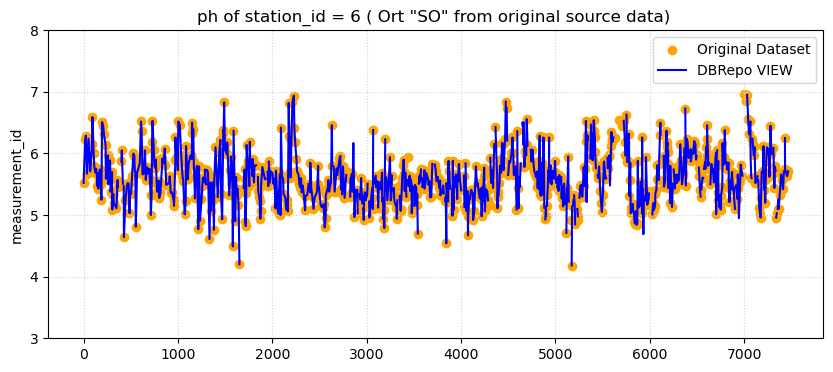

In [28]:
df_7 = df_c.loc [ (df_c.Ort == 'SO') & ( df_c.Pb_flag ==1 ) & ( df_c.Cd_flag == 1 )  ]

x = df_7['index_datum']
y = df_7['pH']


import matplotlib.pyplot as plt

plt.figure(figsize=[10,4])

station_6_data_pb_cd_ph['ph'] = station_6_data_pb_cd_ph['ph'].astype('float').values
station_6_data_pb_cd_ph['pb'] = station_6_data_pb_cd_ph['pb'].astype('float').values
station_6_data_pb_cd_ph['cd'] = station_6_data_pb_cd_ph['cd'].astype('float').values

station_6_data_pb_cd_ph['measurement_id'] = station_6_data_pb_cd_ph['measurement_id'].astype('int').values
station_6_data_pb_cd_ph = station_6_data_pb_cd_ph.sort_values(by=['measurement_id'])


plt.title('ph of station_id = 6 ( Ort "SO" from original source data) ')
plt.scatter( x, y , label= 'Original Dataset', color = 'orange')

plt.plot( list(station_6_data_pb_cd_ph['measurement_id']), 
          list(station_6_data_pb_cd_ph['ph']),
          label= 'DBRepo VIEW', color = 'blue')

plt.ylabel('ph - values')
plt.ylabel('measurement_id')

ax = plt.gca()
ax.set_ylim([3, 8])
plt.grid(ls= ':', color = 'lightgray')
plt.legend()
plt.show()


### Plot Cd and Pb time series from VIEW data

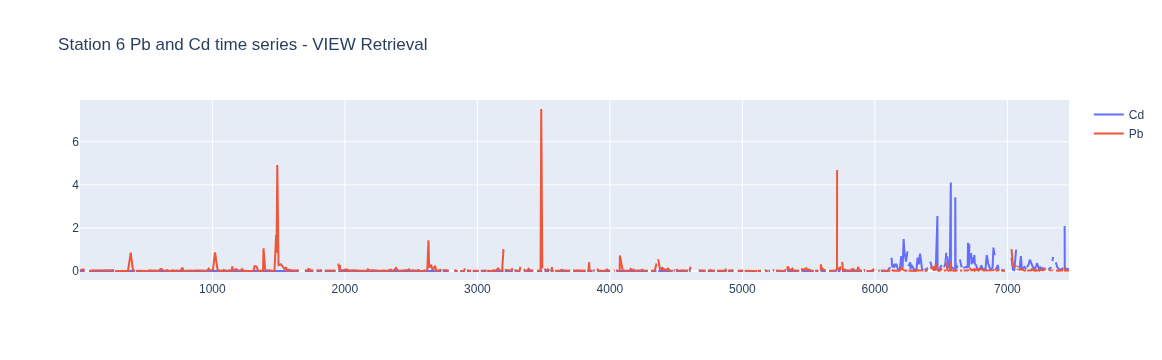

In [30]:

X = station_6_data_pb_cd_ph.measurement_id
CD = station_6_data_pb_cd_ph.pb
PB = station_6_data_pb_cd_ph.cd

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=X, y=CD,
                    mode='lines',
                    name='Cd'))
fig.add_trace(go.Scatter(x=X, y=PB,
                    mode='lines',
                    name='Pb'))


fig.update_layout(
    title = 'Station 6 Pb and Cd time series - VIEW Retrieval'
)

fig.show()

### SQL Query 2. - Stations with large precipitation values

```
SELECT
    station_id,
    ns,
    measurement_id
FROM TABLE_NAME
WHERE ns > 100
ORDER BY measurement_id ASC;
```

In [31]:
TABLE_NAME = 'precipitation_measurements'

## View for stations with the largest precipitation recorded
view_query = QueryDefinition(
    datasources=[TABLE_NAME],
    
    columns=[
        f"{TABLE_NAME}.station_id",
        f"{TABLE_NAME}.ns",
        f"{TABLE_NAME}.measurement_id",
    ],

    filters=[
        FilterDefinition(
            type=FilterType.WHERE,
            column=f"{TABLE_NAME}.ns",
            operator=">",
            value='5',
        )
    ],
    orders=[
        OrderDefinition(
            column=f"{TABLE_NAME}.measurement_id",
            direction=OrderType.ASC,
        )
    ],
)

view = client.create_view(
    database_id=DATABASE_ID,
    name="stations_high_precipitation",
    query=view_query,
    is_public=False,
    is_schema_public=False,
)

print("Created view id:", view.id)
print("Created view name:", view.name)
VIEW_ID = view.id

Created view id: d201a5ae-5d28-4e89-8061-1bca7cf29ac1
Created view name: stations_high_precipitation


In [32]:
print("Waiting for asynchronous view creation to map...")
time.sleep(5)

for _ in range(10):
    try:
        df_view = client.get_view_data(
            database_id=DATABASE_ID,
            view_id=VIEW_ID,
            page=0,
            size=1000000,
        )
        print('df from VIEW created *** ')
        break
    except Exception as e:
        if '204' in str(e):
            print("Still waiting for view...")
            time.sleep(5)
        else:
            raise e

Waiting for asynchronous view creation to map...
df from VIEW created *** 


In [33]:
df_view.head()

,measurement_id,ns,station_id
0,8535,5.834777585210861,3
1,4770,7.6,6
2,694,7.5,9
3,685,7.0,9
4,743,8.3,11


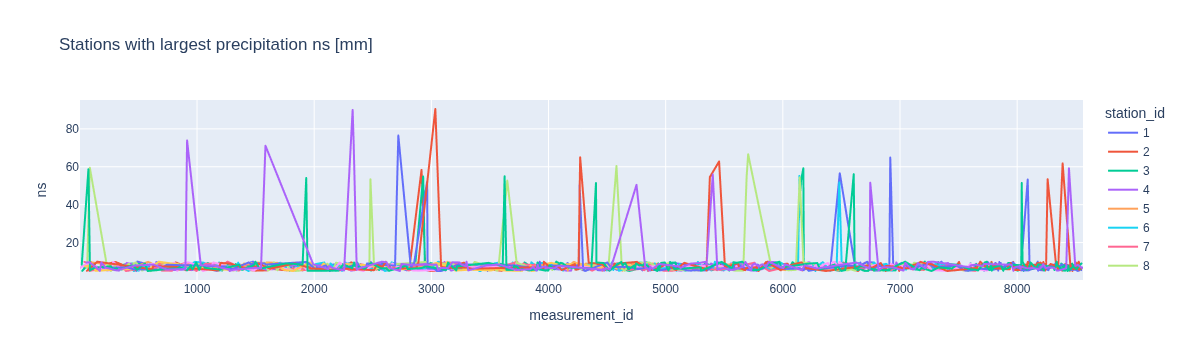

In [34]:
# Formatting DataFrame
stations_high_precipitation = df_view
stations_high_precipitation['measurement_id'] = stations_high_precipitation['measurement_id'].astype('int').values
stations_high_precipitation['ns'] = stations_high_precipitation['ns'].astype('float').values
stations_high_precipitation['station_id'] = stations_high_precipitation['station_id'].astype('int').values
stations_high_precipitation = stations_high_precipitation.sort_values(by=['station_id','measurement_id'])

import plotly.express as px

fig = px.line(stations_high_precipitation, 
                 x="measurement_id", 
                 y="ns", 
                 color="station_id",
                 title="Stations with largest precipitation ns [mm] ")

fig.show()